# Player + Position Based Football Match Prediction

This notebook builds a **pre-match 3-way outcome model** using:

- match history
- rolling team form
- Pi-style dynamic ratings
- FIFAIndex / FC player ratings from 2005–2025
- position-group strength features
- player-point aggregates
- model comparison with cross-validation
- probability calibration
- Brier loss, log loss, RPS, ECE, accuracy and macro-F1

Target classes:

- `H` = home win
- `D` = draw
- `A` = away win

The notebook is designed for the Football Prediction project layout, but all important paths are configurable in the next cell.

This version uses explicit chronological splitting: train up to 2023, validate on 2024-2025, and reserve 2026 for prediction.


## 1. Imports and configuration

Set the paths below if your local folder names are different.

Expected FIFAIndex data can be either:

```text
data/raw_data/fifaindex/csv/*.csv
data/raw_data/fifaindex/parquet/*.parquet
```

Expected match data can be either:

```text
data/raw_data/results.csv
data/raw_data/international/results.csv
raw_data/database.sqlite
```

The notebook also supports common football-data.co.uk style columns such as `Date`, `HomeTeam`, `AwayTeam`, `FTHG`, `FTAG`, `FTR`, `HS`, `AS`, `HST`, `AST`, etc.

In [1]:
from __future__ import annotations

import json
import math
import os
import re
import sqlite3
import unicodedata
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()

RAW_DIR_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw_data"
]

FIFAINDEX_DIR_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw_data" / "fifaindex"
]

# Set to a specific CSV/parquet/database path if auto-discovery chooses the wrong file.
MATCH_FILE_OVERRIDE: Optional[Path] = None
FIFAINDEX_DIR_OVERRIDE: Optional[Path] = None

# "auto" chooses nation-join when the match teams look international, otherwise club/team-join.
# Use "nation" for international football and "team" for club football.
FIFA_JOIN_MODE = "auto"  # "auto", "nation", or "team"

# FIFA game edition mapping:
# "season_release": Sep-Dec 2024 uses FC25, Jan-Aug 2025 also uses FC25.
# "calendar": 2025 match uses FC25 directly.
FIFA_YEAR_MODE = "season_release"  # "season_release" or "calendar"

FORM_WINDOWS = [3, 5, 10]
H2H_WINDOW = 5

# Chronological split used throughout the notebook.
# Train and cross-validate only on matches up to TRAIN_END_YEAR.
# Validate/calibrate/model-select on VALID_START_YEAR to VALID_END_YEAR.
# Keep PREDICT_YEAR out of training and validation.
TRAIN_END_YEAR = 2023
VALID_START_YEAR = 2024
VALID_END_YEAR = 2025
PREDICT_YEAR = 2026

# Expanding-window yearly CV inside the training period only.
# Example: train <=2017, validate 2018; train <=2018, validate 2019; ... train <=2022, validate 2023.
CV_FIRST_VALID_YEAR = 2018
CV_LAST_VALID_YEAR = TRAIN_END_YEAR

CALIBRATION_METHOD = "sigmoid"  # safer than isotonic for smaller calibration windows
CALIBRATION_FRACTION = 0.20      # latest part of each training window used for calibration
MIN_CALIBRATION_ROWS = 100

# High-cardinality team names can overfit. Keep False unless you explicitly want team identity as a feature.
INCLUDE_TEAM_NAMES_AS_CATEGORICAL = False

# Output folders
ARTIFACT_DIR = PROJECT_ROOT / "models" / "player_position_match_model"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Artifact dir:", ARTIFACT_DIR)

Project root: c:\Projects\Football Prediction
Artifact dir: c:\Projects\Football Prediction\models\player_position_match_model


## 2. General utilities

In [2]:
def clean_column_name(col: str) -> str:
    """Standardise column names across scraped files and public football datasets."""
    col = str(col).strip()
    col = re.sub(r"(?<=[a-z0-9])(?=[A-Z])", "_", col)
    col = col.lower()
    col = col.replace("%", "pct")
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col


def normalize_name(value: object) -> str:
    """Normalise team/country/player names for safer joins."""
    if pd.isna(value):
        return ""
    s = str(value).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("&", " and ")
    s = re.sub(r"\bfootball club\b|\bfc\b|\bafc\b|\bcf\b|\bsc\b|\bac\b", " ", s)
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    # Add project-specific aliases here when coverage is low.
    aliases = {
        "man united": "manchester united",
        "man utd": "manchester united",
        "spurs": "tottenham hotspur",
        "inter milan": "internazionale",
        "usa": "united states",
        "usmnt": "united states",
        "ivory coast": "cote d ivoire",
        "czech republic": "czechia",
        "south korea": "korea republic",
        "north korea": "korea dpr",
        "republic of ireland": "ireland",
    }
    return aliases.get(s, s)


def find_first_existing(paths: Iterable[Path]) -> Optional[Path]:
    for path in paths:
        if path and Path(path).exists():
            return Path(path)
    return None


def find_files(base_dirs: Iterable[Path], patterns: Iterable[str]) -> List[Path]:
    files: List[Path] = []
    for base in base_dirs:
        if not base.exists():
            continue
        for pattern in patterns:
            files.extend(base.rglob(pattern))
    return sorted(set(files))


def display_missing_summary(df: pd.DataFrame, top_n: int = 30) -> pd.DataFrame:
    out = (
        df.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .head(top_n)
        .rename("missing_pct")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    return out

## 3. Load and standardise match data

The model must only use features known **before** the match. Current-match scores, current-match shots, cards, corners, etc. are used only to create historical rolling features and are excluded from the final model matrix.

In [3]:
COMMON_MATCH_RENAMES = {
    # football-data.co.uk
    "date": "date",
    "hometeam": "home_team",
    "awayteam": "away_team",
    "fthg": "home_score",
    "ftag": "away_score",
    "ftr": "full_time_result",
    "hthg": "half_time_home_score",
    "htag": "half_time_away_score",
    "htr": "half_time_result",
    "hs": "home_shots",
    "as": "away_shots",
    "hst": "home_shots_on_target",
    "ast": "away_shots_on_target",
    "hf": "home_fouls",
    "af": "away_fouls",
    "hc": "home_corners",
    "ac": "away_corners",
    "hy": "home_yellow_cards",
    "ay": "away_yellow_cards",
    "hr": "home_red_cards",
    "ar": "away_red_cards",

    # common Kaggle/international names already standard after clean_column_name
    "home_score": "home_score",
    "away_score": "away_score",
    "home_team": "home_team",
    "away_team": "away_team",
    "tournament": "tournament",
    "city": "city",
    "country": "country",
    "neutral": "neutral",
    "season": "season",
    "league": "league",
}


def standardise_match_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    original_columns = list(df.columns)
    df.columns = [clean_column_name(c) for c in df.columns]

    rename_map = {}
    for c in df.columns:
        if c in COMMON_MATCH_RENAMES:
            rename_map[c] = COMMON_MATCH_RENAMES[c]
    df = df.rename(columns=rename_map)

    required = {"date", "home_team", "away_team", "home_score", "away_score"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(
            f"Match file is missing required columns after standardisation: {sorted(missing)}\n"
            f"Original columns were: {original_columns}\n"
            f"Standardised columns are: {list(df.columns)}"
        )

    # Date parsing: dayfirst=True handles many European football CSVs.
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"]).copy()

    df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
    df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")
    df = df.dropna(subset=["home_score", "away_score"]).copy()

    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    df["home_team"] = df["home_team"].astype(str).str.strip()
    df["away_team"] = df["away_team"].astype(str).str.strip()
    df["home_team_norm"] = df["home_team"].map(normalize_name)
    df["away_team_norm"] = df["away_team"].map(normalize_name)

    if "neutral" in df.columns:
        df["neutral"] = df["neutral"].astype(str).str.lower().isin(["true", "1", "yes", "y"])
    else:
        df["neutral"] = False

    df = df.sort_values("date").reset_index(drop=True)
    df["match_id"] = np.arange(len(df), dtype=int)

    return df


def candidate_match_files() -> List[Path]:
    if MATCH_FILE_OVERRIDE is not None:
        return [Path(MATCH_FILE_OVERRIDE)]

    candidates: List[Path] = []
    for raw_dir in RAW_DIR_CANDIDATES:
        candidates.extend([
            raw_dir / "results.csv",
            raw_dir / "international" / "results.csv",
            raw_dir / "international-football-results" / "results.csv",
            raw_dir / "matches.csv",
            raw_dir / "match_stats.csv",
        ])

    # Add broad search but de-prioritise tiny helper files such as former_names.csv.
    broad = find_files(RAW_DIR_CANDIDATES, ["*.csv", "*.parquet"])
    broad = [
        p for p in broad
        if p.name.lower() not in {"former_names.csv", "goalscorers.csv", "goal_scorers.csv"}
        and "fifaindex" not in str(p).lower()
    ]
    return candidates + broad


def resolve_match_file(path: Path) -> Path:
    """Accept either a direct file path or a folder and return the best match-results file."""
    path = Path(path)

    if path.is_file():
        return path

    if not path.exists():
        raise FileNotFoundError(f"Path does not exist: {path}")

    if path.is_dir():
        candidate_names = [
            "results.csv",
            "International_football_results.csv",
            "matches.csv",
            "match_results.csv",
            "results.parquet",
            "matches.parquet",
        ]

        for name in candidate_names:
            hits = sorted(path.rglob(name))
            hits = [p for p in hits if "fifaindex" not in str(p).lower()]
            if hits:
                print(f"Using match file from folder: {hits[0]}")
                return hits[0]

        available = [p for p in sorted(path.rglob("*.csv")) if "fifaindex" not in str(p).lower()][:20]
        raise FileNotFoundError(
            "No recognised match-results file found inside folder.\n"
            f"Searched in: {path}\n\n"
            "First CSV files found:\n"
            + "\n".join(str(p) for p in available)
        )

    raise ValueError(f"Unsupported path type: {path}")


def load_matches_from_csv_or_parquet(path: Path) -> pd.DataFrame:
    path = resolve_match_file(Path(path))
    print(f"Loading match file: {path}")

    if path.suffix.lower() == ".parquet":
        raw = pd.read_parquet(path)
    elif path.suffix.lower() == ".csv":
        raw = pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported match file type: {path}")

    return standardise_match_columns(raw)


def find_sqlite_database() -> Optional[Path]:
    if MATCH_FILE_OVERRIDE is not None and Path(MATCH_FILE_OVERRIDE).suffix.lower() in {".sqlite", ".db"}:
        return Path(MATCH_FILE_OVERRIDE)

    candidates = []
    for raw_dir in RAW_DIR_CANDIDATES:
        candidates.extend([
            raw_dir / "database.sqlite",
            raw_dir / "database.db",
        ])
    candidates.extend(find_files(RAW_DIR_CANDIDATES, ["*.sqlite", "*.db"]))
    return find_first_existing(candidates)


def load_matches_from_european_sqlite(path: Path) -> pd.DataFrame:
    """Load the Kaggle European Soccer Database style Match + Team tables."""
    print(f"Loading SQLite match database: {path}")
    with sqlite3.connect(path) as conn:
        query = """
        SELECT
            m.id AS source_match_id,
            m.date AS date,
            m.season AS season,
            l.name AS league,
            ht.team_long_name AS home_team,
            at.team_long_name AS away_team,
            m.home_team_goal AS home_score,
            m.away_team_goal AS away_score
        FROM Match m
        LEFT JOIN Team ht ON m.home_team_api_id = ht.team_api_id
        LEFT JOIN Team at ON m.away_team_api_id = at.team_api_id
        LEFT JOIN League l ON m.league_id = l.id
        WHERE m.home_team_goal IS NOT NULL
          AND m.away_team_goal IS NOT NULL
        """
        raw = pd.read_sql_query(query, conn)

    return standardise_match_columns(raw)


def load_match_data() -> pd.DataFrame:
    # First try explicit/common CSV/parquet files.
    for path in candidate_match_files():
        path = Path(path)
        if not path.exists():
            continue
        try:
            return load_matches_from_csv_or_parquet(path)
        except Exception as exc:
            print(f"Skipped {path.name}: {exc}")

    # Then try SQLite.
    sqlite_path = find_sqlite_database()
    if sqlite_path is not None and sqlite_path.exists():
        return load_matches_from_european_sqlite(sqlite_path)

    raise FileNotFoundError(
        "Could not auto-load match data. Set MATCH_FILE_OVERRIDE to your results/matches CSV, parquet, or database.sqlite path."
    )


matches = load_match_data()
print(matches.shape)
matches.head()

Loading match file: c:\Projects\Football Prediction\data\raw_data\elo_ratings\eloratings.csv
Skipped eloratings.csv: Match file is missing required columns after standardisation: ['away_score', 'away_team', 'home_score', 'home_team']
Original columns were: ['date', 'team', 'rating', 'change']
Standardised columns are: ['date', 'team', 'rating', 'change']
Loading match file: c:\Projects\Football Prediction\data\raw_data\european_league_matches\csv\country.csv
Skipped country.csv: Match file is missing required columns after standardisation: ['away_score', 'away_team', 'date', 'home_score', 'home_team']
Original columns were: ['id', 'name']
Standardised columns are: ['id', 'name']
Loading match file: c:\Projects\Football Prediction\data\raw_data\european_league_matches\csv\league.csv
Skipped league.csv: Match file is missing required columns after standardisation: ['away_score', 'away_team', 'date', 'home_score', 'home_team']
Original columns were: ['id', 'country_id', 'name']
Standardis

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_team_norm,away_team_norm,match_id
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,scotland,england,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,england,scotland,1
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,scotland,england,2
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,england,scotland,3
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,scotland,england,4


In [4]:
def add_outcome_target(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def outcome(row):
        if row["home_score"] > row["away_score"]:
            return "H"
        if row["home_score"] < row["away_score"]:
            return "A"
        return "D"

    df["outcome"] = df.apply(outcome, axis=1)

    # Stable numeric encoding for all models, especially XGBoost.
    # 0=H, 1=D, 2=A
    outcome_to_code = {"H": 0, "D": 1, "A": 2}
    df["outcome_code"] = df["outcome"].map(outcome_to_code).astype(int)
    return df


matches = add_outcome_target(matches)

print(matches["outcome"].value_counts(normalize=True).rename("class_share"))
matches[["date", "home_team", "away_team", "home_score", "away_score", "outcome"]].head()

outcome
H    0.490102
A    0.282470
D    0.227428
Name: class_share, dtype: float64


,date,home_team,away_team,home_score,away_score,outcome
0,1872-11-30,Scotland,England,0,0,D
1,1873-03-08,England,Scotland,4,2,H
2,1874-03-07,Scotland,England,2,1,H
3,1875-03-06,England,Scotland,2,2,D
4,1876-03-04,Scotland,England,3,0,H


## 4. Team form features from match history

For each team, we create rolling pre-match features such as:

- average points over last 3, 5 and 10 matches
- average goals for / against
- rolling goal difference
- win/draw/loss rates
- rolling historical match-stat averages when those columns exist
- days since previous match

Every rolling feature uses `.shift()` so the current match is not included.

In [5]:
def find_side_stat_pairs(df: pd.DataFrame) -> List[Tuple[str, str, str]]:
    """Find columns like home_shots / away_shots and return (home_col, away_col, base_name)."""
    pairs: List[Tuple[str, str, str]] = []
    exclude_bases = {
        "team", "team_norm", "score", "result", "goals", "goal",
        "player", "formation", "lineup"
    }

    for col in df.columns:
        if not col.startswith("home_"):
            continue
        base = col[len("home_"):]
        away_col = f"away_{base}"
        if away_col not in df.columns:
            continue
        if base in exclude_bases or "score" in base:
            continue
        if pd.api.types.is_numeric_dtype(df[col]) and pd.api.types.is_numeric_dtype(df[away_col]):
            pairs.append((col, away_col, base))
    return pairs


def build_team_match_rows(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    df = df.copy()
    side_stat_pairs = find_side_stat_pairs(df)
    side_stat_bases = [base for _, _, base in side_stat_pairs]

    home = pd.DataFrame({
        "match_id": df["match_id"],
        "date": df["date"],
        "team_norm": df["home_team_norm"],
        "opponent_norm": df["away_team_norm"],
        "is_home": 1,
        "gf": df["home_score"],
        "ga": df["away_score"],
    })

    away = pd.DataFrame({
        "match_id": df["match_id"],
        "date": df["date"],
        "team_norm": df["away_team_norm"],
        "opponent_norm": df["home_team_norm"],
        "is_home": 0,
        "gf": df["away_score"],
        "ga": df["home_score"],
    })

    for home_col, away_col, base in side_stat_pairs:
        home[base] = pd.to_numeric(df[home_col], errors="coerce")
        away[base] = pd.to_numeric(df[away_col], errors="coerce")

    team_rows = pd.concat([home, away], ignore_index=True)
    team_rows["gd"] = team_rows["gf"] - team_rows["ga"]
    team_rows["win"] = (team_rows["gd"] > 0).astype(int)
    team_rows["draw"] = (team_rows["gd"] == 0).astype(int)
    team_rows["loss"] = (team_rows["gd"] < 0).astype(int)
    team_rows["points"] = np.select(
        [team_rows["win"].eq(1), team_rows["draw"].eq(1)],
        [3, 1],
        default=0,
    )

    team_rows = team_rows.sort_values(["team_norm", "date", "match_id"]).reset_index(drop=True)
    team_rows["days_since_last_match"] = team_rows.groupby("team_norm")["date"].diff().dt.days

    rolling_base_cols = ["points", "gf", "ga", "gd", "win", "draw", "loss"] + side_stat_bases

    for window in FORM_WINDOWS:
        for col in rolling_base_cols:
            team_rows[f"{col}_avg_l{window}"] = (
                team_rows
                .groupby("team_norm")[col]
                .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
            )

        team_rows[f"matches_available_l{window}"] = (
            team_rows
            .groupby("team_norm")["points"]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=1).count())
        )

    return team_rows, side_stat_bases


def merge_team_form(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    team_rows, side_stat_bases = build_team_match_rows(df)

    form_cols = [
        c for c in team_rows.columns
        if any(c.endswith(f"_l{w}") for w in FORM_WINDOWS)
        or c == "days_since_last_match"
    ]

    home_form = (
        team_rows[team_rows["is_home"].eq(1)][["match_id"] + form_cols]
        .rename(columns={c: f"home_form_{c}" for c in form_cols})
    )
    away_form = (
        team_rows[team_rows["is_home"].eq(0)][["match_id"] + form_cols]
        .rename(columns={c: f"away_form_{c}" for c in form_cols})
    )

    out = df.merge(home_form, on="match_id", how="left").merge(away_form, on="match_id", how="left")

    for col in form_cols:
        h = f"home_form_{col}"
        a = f"away_form_{col}"
        if h in out.columns and a in out.columns:
            out[f"diff_form_{col}"] = out[h] - out[a]

    return out


matches_form = merge_team_form(matches)
print(matches_form.shape)
matches_form.filter(regex="form_|diff_form_").head()

(49453, 89)


,home_form_days_since_last_match,home_form_points_avg_l3,home_form_gf_avg_l3,home_form_ga_avg_l3,home_form_gd_avg_l3,home_form_win_avg_l3,home_form_draw_avg_l3,home_form_loss_avg_l3,home_form_matches_available_l3,home_form_points_avg_l5,...,diff_form_loss_avg_l5,diff_form_matches_available_l5,diff_form_points_avg_l10,diff_form_gf_avg_l10,diff_form_ga_avg_l10,diff_form_gd_avg_l10,diff_form_win_avg_l10,diff_form_draw_avg_l10,diff_form_loss_avg_l10,diff_form_matches_available_l10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,98.0,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0,1.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,364.0,0.500000,1.000000,2.000000,-1.000000,0.000000,0.500000,0.500000,2.0,0.500000,...,0.5,0.0,-1.5,-1.000000,1.000000,-2.000000,-0.5,0.0,0.5,0.0
3,364.0,1.333333,1.666667,1.333333,0.333333,0.333333,0.333333,0.333333,3.0,1.333333,...,0.0,0.0,0.0,0.333333,-0.333333,0.666667,0.0,0.0,0.0,0.0
4,364.0,1.333333,2.000000,2.333333,-0.333333,0.333333,0.333333,0.333333,3.0,1.250000,...,0.0,0.0,0.0,-0.250000,0.250000,-0.500000,0.0,0.0,0.0,0.0


## 5. Pi-style ratings

This is a dynamic pre-match rating system with separate home and away ratings for each team.

For each match:

1. store both teams' ratings before the match
2. calculate expected goal difference
3. update ratings after the match using the prediction error

Only pre-match rating values are used as model features.

In [6]:
def add_pi_ratings(
    df: pd.DataFrame,
    alpha: float = 0.035,
    away_home_transfer: float = 0.70,
    initial_rating: float = 0.0,
) -> pd.DataFrame:
    df = df.sort_values(["date", "match_id"]).copy()
    ratings: Dict[str, Dict[str, float]] = defaultdict(
        lambda: {"home": initial_rating, "away": initial_rating}
    )

    records = []

    for row in df.itertuples(index=False):
        home = row.home_team_norm
        away = row.away_team_norm

        home_home_pre = ratings[home]["home"]
        home_away_pre = ratings[home]["away"]
        away_home_pre = ratings[away]["home"]
        away_away_pre = ratings[away]["away"]

        expected_goal_diff = home_home_pre - away_away_pre
        actual_goal_diff = row.home_score - row.away_score
        error = actual_goal_diff - expected_goal_diff

        records.append({
            "match_id": row.match_id,
            "home_pi_home_pre": home_home_pre,
            "home_pi_away_pre": home_away_pre,
            "away_pi_home_pre": away_home_pre,
            "away_pi_away_pre": away_away_pre,
            "pi_expected_goal_diff": expected_goal_diff,
            "pi_home_advantage_rating_diff": home_home_pre - home_away_pre,
            "pi_away_travel_rating_diff": away_home_pre - away_away_pre,
            "pi_rating_diff": (home_home_pre + home_away_pre) / 2 - (away_home_pre + away_away_pre) / 2,
        })

        # Update home team's home rating and partially update its away rating.
        ratings[home]["home"] += alpha * error
        ratings[home]["away"] += alpha * away_home_transfer * error

        # Symmetric update for away team.
        ratings[away]["away"] -= alpha * error
        ratings[away]["home"] -= alpha * away_home_transfer * error

    pi_df = pd.DataFrame(records)
    return df.merge(pi_df, on="match_id", how="left")


matches_pi = add_pi_ratings(matches_form)
matches_pi.filter(regex="pi_").head()

,home_pi_home_pre,home_pi_away_pre,away_pi_home_pre,away_pi_away_pre,pi_expected_goal_diff,pi_home_advantage_rating_diff,pi_away_travel_rating_diff,pi_rating_diff
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-0.049000,-0.070000,0.070000,0.049000,-0.098000,0.021000,0.021000,-0.119000
3,0.043099,0.010570,-0.010570,-0.043099,0.086198,0.032529,0.032529,0.053669
4,-0.008458,-0.040082,0.040082,0.008458,-0.016916,0.031624,0.031624,-0.048540


## 6. Head-to-head features

In [7]:
def add_h2h_features(df: pd.DataFrame, window: int = H2H_WINDOW) -> pd.DataFrame:
    df = df.sort_values(["date", "match_id"]).copy()
    history: Dict[Tuple[str, str], List[dict]] = defaultdict(list)
    records = []

    for row in df.itertuples(index=False):
        home = row.home_team_norm
        away = row.away_team_norm
        key = tuple(sorted([home, away]))
        past = history[key][-window:]

        if past:
            home_points = []
            home_gd = []
            for m in past:
                if m["home"] == home:
                    home_points.append(m["home_points"])
                    home_gd.append(m["home_gd"])
                else:
                    home_points.append(m["away_points"])
                    home_gd.append(m["away_gd"])

            h2h_home_points_avg = float(np.mean(home_points))
            h2h_home_gd_avg = float(np.mean(home_gd))
            h2h_matches = len(past)
        else:
            h2h_home_points_avg = np.nan
            h2h_home_gd_avg = np.nan
            h2h_matches = 0

        records.append({
            "match_id": row.match_id,
            f"h2h_home_points_avg_l{window}": h2h_home_points_avg,
            f"h2h_home_gd_avg_l{window}": h2h_home_gd_avg,
            f"h2h_matches_available_l{window}": h2h_matches,
        })

        home_gd_now = row.home_score - row.away_score
        away_gd_now = -home_gd_now
        home_points_now = 3 if home_gd_now > 0 else 1 if home_gd_now == 0 else 0
        away_points_now = 3 if away_gd_now > 0 else 1 if away_gd_now == 0 else 0

        history[key].append({
            "home": home,
            "away": away,
            "home_points": home_points_now,
            "away_points": away_points_now,
            "home_gd": home_gd_now,
            "away_gd": away_gd_now,
        })

    return df.merge(pd.DataFrame(records), on="match_id", how="left")


matches_feature_base = add_h2h_features(matches_pi)
matches_feature_base.filter(regex="h2h_").head()

,h2h_home_points_avg_l5,h2h_home_gd_avg_l5,h2h_matches_available_l5
0,NaN,NaN,0
1,1.000000,0.000000,1
2,0.500000,-1.000000,2
3,1.333333,0.333333,3
4,1.250000,-0.250000,4


## 7. Load FIFAIndex / FC player files

This loader accepts all CSV/parquet files under your FIFAIndex folder and infers the game year from either:

- `game_version` column
- file/folder name such as `fc25`, `fifa25`, `fifa_25`, `players_2025`, etc.

The player-level data is then converted into team/nation season aggregates.

In [8]:
def find_fifaindex_dir() -> Path:
    if FIFAINDEX_DIR_OVERRIDE is not None:
        path = Path(FIFAINDEX_DIR_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    path = find_first_existing(FIFAINDEX_DIR_CANDIDATES)
    if path is None:
        raise FileNotFoundError(
            "Could not find FIFAIndex directory. Set FIFAINDEX_DIR_OVERRIDE to your fifaindex folder."
        )
    return path


def infer_game_year_from_text(text: str) -> Optional[int]:
    text = str(text).lower()

    # Explicit full years first.
    full_year_match = re.search(r"(20[0-2][0-9])", text)
    if full_year_match:
        year = int(full_year_match.group(1))
        if 2005 <= year <= 2026:
            return year

    # fc25, fifa25, fifa_25, fifa-05, etc.
    short_match = re.search(r"(?:fc|fifa)[_\-\s]?(\d{2})", text)
    if short_match:
        yy = int(short_match.group(1))
        if 0 <= yy <= 30:
            return 2000 + yy

    # Any standalone 05..26 token.
    yy_match = re.search(r"(?:^|[_\-\s])(\d{2})(?:$|[_\-\s])", text)
    if yy_match:
        yy = int(yy_match.group(1))
        if 5 <= yy <= 30:
            return 2000 + yy

    return None


def load_one_fifa_file(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path)

    df.columns = [clean_column_name(c) for c in df.columns]

    # Common alternatives from different scrapers.
    rename_candidates = {
        "name": "player",
        "player_name": "player",
        "club": "team",
        "club_team": "team",
        "nationality": "nation",
        "overall": "ovr",
        "potential": "pot",
        "positions": "position",
        "preferred_position": "position",
    }
    df = df.rename(columns={c: rename_candidates[c] for c in df.columns if c in rename_candidates})

    # Infer game year.
    if "game_year" not in df.columns:
        if "game_version" in df.columns:
            year_from_col = df["game_version"].dropna().astype(str).map(infer_game_year_from_text)
            year = year_from_col.dropna().iloc[0] if year_from_col.notna().any() else None
        else:
            year = None

        if year is None:
            year = infer_game_year_from_text(str(path))

        df["game_year"] = year

    df["source_file"] = str(path)
    return df


def load_fifaindex_data() -> pd.DataFrame:
    fifa_dir = find_fifaindex_dir()
    files = sorted(
        list((fifa_dir / "csv").rglob("*.csv")) +
        list((fifa_dir / "parquet").rglob("*.parquet")) +
        list(fifa_dir.rglob("*.csv")) +
        list(fifa_dir.rglob("*.parquet"))
    )
    files = sorted(set(files))

    if not files:
        raise FileNotFoundError(f"No FIFAIndex CSV/parquet files found under {fifa_dir}")

    frames = []
    skipped = []
    for path in files:
        try:
            frame = load_one_fifa_file(path)
            frames.append(frame)
        except Exception as exc:
            skipped.append((path, str(exc)))

    if skipped:
        print(f"Skipped {len(skipped)} FIFA files:")
        for path, msg in skipped[:10]:
            print(" -", path, "=>", msg)

    if not frames:
        raise ValueError("No FIFAIndex files could be loaded.")

    fifa = pd.concat(frames, ignore_index=True)
    fifa.columns = [clean_column_name(c) for c in fifa.columns]

    print(f"Loaded FIFAIndex rows: {len(fifa):,}")
    print(f"Loaded files: {len(files):,}")
    print("Columns:", list(fifa.columns)[:40])
    return fifa


fifa_raw = load_fifaindex_data()
fifa_raw.head()

Loaded FIFAIndex rows: 4,950,432
Loaded files: 222
Columns: ['player', 'position', 'nation', 'team', 'ovr', 'pot', 'source_position_code', 'source_position_group', 'source_page', 'scrape_source', 'game_version', 'game_version_slug', 'game_year', 'source_file']


,player,position,nation,team,ovr,pot,source_position_code,source_position_group,source_page,scrape_source,game_version,game_version_slug,game_year,source_file
0,Thibaut Courtois,GK,Belgium,Real Madrid,90,90,gk,goalkeeper,1,fifaindex,FC 24,fc24,2024,c:\Projects\Football Prediction\data\raw_data\...
1,Marc-André ter Stegen,GK,Germany,FC Barcelona,89,89,gk,goalkeeper,1,fifaindex,FC 24,fc24,2024,c:\Projects\Football Prediction\data\raw_data\...
2,Alisson,GK,Brazil,Liverpool,89,89,gk,goalkeeper,1,fifaindex,FC 24,fc24,2024,c:\Projects\Football Prediction\data\raw_data\...
3,Jan Oblak,GK,Slovenia,Atlético de Madrid,88,88,gk,goalkeeper,1,fifaindex,FC 24,fc24,2024,c:\Projects\Football Prediction\data\raw_data\...
4,Ederson,GK,Brazil,Manchester City,88,89,gk,goalkeeper,1,fifaindex,FC 24,fc24,2024,c:\Projects\Football Prediction\data\raw_data\...


In [9]:
def infer_position_group(position: object) -> str:
    pos = str(position).upper()
    tokens = set(re.split(r"[^A-Z0-9]+", pos))

    if "GK" in tokens or pos == "GOALKEEPER":
        return "gk"

    defender_tokens = {"CB", "LB", "RB", "LWB", "RWB", "SW", "DEF", "DF"}
    midfielder_tokens = {"CM", "CDM", "CAM", "LM", "RM", "MID", "MF"}
    attacker_tokens = {"ST", "CF", "LW", "RW", "LF", "RF", "SS", "ATT", "FW"}

    if tokens.intersection(defender_tokens):
        return "def"
    if tokens.intersection(midfielder_tokens):
        return "mid"
    if tokens.intersection(attacker_tokens):
        return "att"
    return "unknown"


def coalesce_column(df: pd.DataFrame, candidates: List[str], default=np.nan) -> pd.Series:
    for col in candidates:
        if col in df.columns:
            return df[col]
    return pd.Series(default, index=df.index)


def standardise_fifa_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [clean_column_name(c) for c in df.columns]

    # Required minimum fields with fallbacks.
    df["player"] = coalesce_column(df, ["player", "name", "player_name"], "")
    df["team"] = coalesce_column(df, ["team", "club", "club_team"], "")
    df["nation"] = coalesce_column(df, ["nation", "nationality", "country"], "")
    df["position"] = coalesce_column(df, ["position", "positions", "preferred_position"], "")

    if "source_position_group" in df.columns:
        df["position_group"] = df["source_position_group"].astype(str).str.lower()
        df["position_group"] = df["position_group"].replace({
            "goalkeeper": "gk",
            "defender": "def",
            "midfielder": "mid",
            "attacker": "att",
            "attack": "att",
        })
    else:
        df["position_group"] = df["position"].map(infer_position_group)

    for col in ["ovr", "pot", "game_year"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["game_year"]).copy()
    df["game_year"] = df["game_year"].astype(int)

    # Keep the range the user has collected.
    df = df[df["game_year"].between(2005, 2025)].copy()

    df["team_norm"] = df["team"].map(normalize_name)
    df["nation_norm"] = df["nation"].map(normalize_name)
    df["player_norm"] = df["player"].map(normalize_name)

    # Convert any numeric-looking columns.
    for col in df.columns:
        if col in {"game_year"}:
            continue
        if df[col].dtype == "object":
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().mean() > 0.65:
                df[col] = converted

    # Avoid exact duplicate rows from position-group scrapes.
    dedupe_cols = [c for c in ["game_year", "player_norm", "team_norm", "nation_norm", "position"] if c in df.columns]
    df = df.drop_duplicates(subset=dedupe_cols).reset_index(drop=True)

    return df


fifa = standardise_fifa_data(fifa_raw)

print(fifa.shape)
print("Game years:", sorted(fifa["game_year"].dropna().unique())[:5], "...", sorted(fifa["game_year"].dropna().unique())[-5:])
print("Position groups:")
print(fifa["position_group"].value_counts(dropna=False))
fifa[["game_year", "player", "team", "nation", "position", "position_group", "ovr", "pot"]].head()

(434569, 18)
Game years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009)] ... [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Position groups:
position_group
gk     353327
def     33379
mid     27154
att     20709
Name: count, dtype: int64


,game_year,player,team,nation,position,position_group,ovr,pot
0,2024,Thibaut Courtois,Real Madrid,Belgium,GK,gk,90,90
1,2024,Marc-André ter Stegen,FC Barcelona,Germany,GK,gk,89,89
2,2024,Alisson,Liverpool,Brazil,GK,gk,89,89
3,2024,Jan Oblak,Atlético de Madrid,Slovenia,GK,gk,88,88
4,2024,Ederson,Manchester City,Brazil,GK,gk,88,89


## 8. Player points and position-based aggregates

`player_points` is a single player-strength score. It uses `ovr` and `pot` for every dataset, then adds position-relevant stat columns when available.

Examples:

- GK: goalkeeper/diving/handling/reflex/kicking/positioning columns
- DEF: defending, physical, pace
- MID: passing, dribbling, pace
- ATT: shooting, dribbling, pace

If your scrape only contains `ovr` and `pot`, the notebook still works.

In [10]:
def available_columns(df: pd.DataFrame, patterns: List[str]) -> List[str]:
    out = []
    for col in df.columns:
        for pat in patterns:
            if re.search(pat, col):
                out.append(col)
                break
    return sorted(set(out))


def compute_player_points(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "ovr" not in df.columns:
        raise ValueError("FIFAIndex data needs an overall rating column: 'ovr' or 'overall'.")
    if "pot" not in df.columns:
        df["pot"] = df["ovr"]

    df["ovr"] = pd.to_numeric(df["ovr"], errors="coerce")
    df["pot"] = pd.to_numeric(df["pot"], errors="coerce")
    df["player_points"] = 0.70 * df["ovr"] + 0.30 * df["pot"]

    stat_patterns = {
        "gk": [r"gk", r"div", r"han", r"reflex", r"kicking", r"positioning"],
        "def": [r"def", r"mark", r"tackle", r"intercept", r"physical", r"strength", r"pace"],
        "mid": [r"pas", r"pass", r"vision", r"drib", r"ball_control", r"stamina", r"pace"],
        "att": [r"sho", r"shot", r"finish", r"attack", r"drib", r"pace", r"composure"],
    }

    for group, patterns in stat_patterns.items():
        cols = [
            c for c in available_columns(df, patterns)
            if c not in {"ovr", "pot", "game_year", "source_page"} and pd.api.types.is_numeric_dtype(df[c])
        ]
        cols = cols[:12]  # cap to avoid overweighting very detailed scrapes

        if cols:
            stat_score = df[cols].mean(axis=1)
            mask = df["position_group"].eq(group)
            df.loc[mask, "player_points"] = (
                0.60 * df.loc[mask, "ovr"] +
                0.20 * df.loc[mask, "pot"] +
                0.20 * stat_score.loc[mask]
            )

    return df


fifa = compute_player_points(fifa)
fifa[["game_year", "player", "position_group", "ovr", "pot", "player_points"]].head()

,game_year,player,position_group,ovr,pot,player_points
0,2024,Thibaut Courtois,gk,90,90,90.0
1,2024,Marc-André ter Stegen,gk,89,89,89.0
2,2024,Alisson,gk,89,89,89.0
3,2024,Jan Oblak,gk,88,88,88.0
4,2024,Ederson,gk,88,89,88.3


In [11]:
def safe_nlargest_mean(s: pd.Series, n: int) -> float:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return float(s.nlargest(min(n, len(s))).mean())


def aggregate_fifa_strength(df: pd.DataFrame, key_col: str, key_out: str) -> pd.DataFrame:
    """Aggregate player-level FIFA ratings by team/nation and game year."""
    d = df.copy()
    d[key_out] = d[key_col]
    d = d[d[key_out].notna() & d[key_out].ne("")].copy()

    keys = [key_out, "game_year"]

    base = (
        d.groupby(keys)
        .agg(
            fifa_players=("player_norm", "nunique"),
            fifa_avg_ovr=("ovr", "mean"),
            fifa_med_ovr=("ovr", "median"),
            fifa_max_ovr=("ovr", "max"),
            fifa_avg_pot=("pot", "mean"),
            fifa_max_pot=("pot", "max"),
            fifa_avg_player_points=("player_points", "mean"),
            fifa_max_player_points=("player_points", "max"),
        )
        .reset_index()
    )

    top = (
        d.groupby(keys)
        .apply(lambda g: pd.Series({
            "fifa_top11_ovr": safe_nlargest_mean(g["ovr"], 11),
            "fifa_top18_ovr": safe_nlargest_mean(g["ovr"], 18),
            "fifa_top11_player_points": safe_nlargest_mean(g["player_points"], 11),
            "fifa_top18_player_points": safe_nlargest_mean(g["player_points"], 18),
        }))
        .reset_index()
    )

    pos = (
        d[d["position_group"].isin(["gk", "def", "mid", "att"])]
        .groupby(keys + ["position_group"])
        .agg(
            pos_players=("player_norm", "nunique"),
            pos_avg_ovr=("ovr", "mean"),
            pos_top3_ovr=("ovr", lambda s: safe_nlargest_mean(s, 3)),
            pos_avg_pot=("pot", "mean"),
            pos_avg_player_points=("player_points", "mean"),
            pos_top3_player_points=("player_points", lambda s: safe_nlargest_mean(s, 3)),
        )
        .reset_index()
    )

    if not pos.empty:
        pos_pivot = pos.pivot_table(
            index=keys,
            columns="position_group",
            values=[
                "pos_players",
                "pos_avg_ovr",
                "pos_top3_ovr",
                "pos_avg_pot",
                "pos_avg_player_points",
                "pos_top3_player_points",
            ],
            aggfunc="first",
        )
        pos_pivot.columns = [f"fifa_{metric}_{group}" for metric, group in pos_pivot.columns]
        pos_pivot = pos_pivot.reset_index()
    else:
        pos_pivot = pd.DataFrame(columns=keys)

    # Add averages of any extra FIFA numeric stats. Keep only a capped set to avoid extremely wide feature matrices.
    protected = {
        "game_year", "ovr", "pot", "player_points",
        "source_page", "fifa_players"
    }
    numeric_cols = [
        c for c in d.select_dtypes(include=[np.number]).columns
        if c not in protected and not c.startswith("unnamed")
    ]
    numeric_cols = numeric_cols[:40]

    if numeric_cols:
        extra = d.groupby(keys)[numeric_cols].mean().reset_index()
        extra = extra.rename(columns={c: f"fifa_stat_avg_{c}" for c in numeric_cols})
    else:
        extra = pd.DataFrame(columns=keys)

    out = base.merge(top, on=keys, how="left").merge(pos_pivot, on=keys, how="left")
    if not extra.empty:
        out = out.merge(extra, on=keys, how="left")

    return out


fifa_team = aggregate_fifa_strength(fifa, "team_norm", "fifa_entity_norm")
fifa_nation = aggregate_fifa_strength(fifa, "nation_norm", "fifa_entity_norm")

print("Team aggregate:", fifa_team.shape)
print("Nation aggregate:", fifa_nation.shape)
fifa_team.head()

Team aggregate: (12524, 38)
Nation aggregate: (3231, 38)


,fifa_entity_norm,game_year,fifa_players,fifa_avg_ovr,fifa_med_ovr,fifa_max_ovr,fifa_avg_pot,fifa_max_pot,fifa_avg_player_points,fifa_max_player_points,...,fifa_pos_players_gk,fifa_pos_players_mid,fifa_pos_top3_ovr_att,fifa_pos_top3_ovr_def,fifa_pos_top3_ovr_gk,fifa_pos_top3_ovr_mid,fifa_pos_top3_player_points_att,fifa_pos_top3_player_points_def,fifa_pos_top3_player_points_gk,fifa_pos_top3_player_points_mid
0,1 brno,2010,30,58.833333,58.0,73,67.500000,78,61.433333,73.9,...,30.0,NaN,NaN,NaN,71.333333,NaN,NaN,NaN,72.533333,NaN
1,1 ffc turbine potsdam,2025,32,65.656250,68.0,73,72.750000,79,67.784375,73.6,...,3.0,5.0,69.333333,70.0,67.333333,69.333333,70.90,71.3,69.233333,70.333333
2,1 fk pribram,2009,30,50.366667,48.5,66,60.300000,71,53.346667,67.5,...,30.0,NaN,NaN,NaN,65.333333,NaN,NaN,NaN,66.833333,NaN
3,1 fk pribram,2010,30,54.500000,54.0,68,63.800000,76,57.290000,69.5,...,30.0,NaN,NaN,NaN,67.000000,NaN,NaN,NaN,68.700000,NaN
4,1 fk pribram,2011,23,59.130435,59.0,70,66.695652,75,61.400000,70.6,...,20.0,NaN,69.000000,60.0,64.000000,NaN,70.35,61.2,65.900000,NaN


## 9. Merge FIFA features into matches

For each match, the notebook maps the match date to a FIFA/FC game year and then joins both home and away team strengths.

The default `season_release` mapping is:

- Sep-Dec 2024 -> FC25
- Jan-Aug 2025 -> FC25
- Sep-Dec 2023 -> FC24
- etc.

That is a practical approximation for pre-match modelling across football seasons.

In [12]:
def match_to_fifa_year(date: pd.Timestamp, mode: str = FIFA_YEAR_MODE) -> int:
    if pd.isna(date):
        return np.nan
    if mode == "calendar":
        return int(date.year)
    if mode == "season_release":
        # Sep-Dec uses next year's game edition, Jan-Aug uses current year.
        return int(date.year + (date.month >= 9))
    raise ValueError("FIFA_YEAR_MODE must be 'calendar' or 'season_release'.")


def fifa_join_coverage(matches_df: pd.DataFrame, fifa_agg: pd.DataFrame) -> float:
    keys = set(fifa_agg["fifa_entity_norm"].dropna().unique())
    teams = pd.concat([matches_df["home_team_norm"], matches_df["away_team_norm"]]).dropna().unique()
    if len(teams) == 0:
        return 0.0
    return float(np.mean([t in keys for t in teams]))


def choose_fifa_join_table(matches_df: pd.DataFrame) -> Tuple[str, pd.DataFrame]:
    team_cov = fifa_join_coverage(matches_df, fifa_team)
    nation_cov = fifa_join_coverage(matches_df, fifa_nation)

    print(f"FIFA join coverage by club/team name: {team_cov:.1%}")
    print(f"FIFA join coverage by nation name:    {nation_cov:.1%}")

    if FIFA_JOIN_MODE == "team":
        return "team", fifa_team
    if FIFA_JOIN_MODE == "nation":
        return "nation", fifa_nation

    if nation_cov > team_cov:
        return "nation", fifa_nation
    return "team", fifa_team


def asof_merge_fifa_side(
    matches_df: pd.DataFrame,
    fifa_agg: pd.DataFrame,
    side: str,
    team_norm_col: str,
) -> pd.DataFrame:
    """Join latest FIFA aggregate with game_year <= match_fifa_year for one side."""
    left = matches_df[["match_id", team_norm_col, "match_fifa_year"]].copy()
    left = left.rename(columns={team_norm_col: "fifa_entity_norm"})

    left = left.dropna(subset=["match_fifa_year", "fifa_entity_norm"]).copy()
    right = fifa_agg.dropna(subset=["game_year", "fifa_entity_norm"]).copy()

    # merge_asof is strict: both as-of keys must have the exact same dtype.
    left["match_fifa_year"] = pd.to_numeric(left["match_fifa_year"], errors="coerce").astype("int64")
    right["game_year"] = pd.to_numeric(right["game_year"], errors="coerce").astype("int64")
    left["fifa_entity_norm"] = left["fifa_entity_norm"].astype(str)
    right["fifa_entity_norm"] = right["fifa_entity_norm"].astype(str)

    # pandas merge_asof expects the as-of key to be sorted.
    left = left.sort_values(["match_fifa_year", "fifa_entity_norm", "match_id"])
    right = right.sort_values(["game_year", "fifa_entity_norm"])

    merged = pd.merge_asof(
        left,
        right,
        left_on="match_fifa_year",
        right_on="game_year",
        by="fifa_entity_norm",
        direction="backward",
        allow_exact_matches=True,
    )

    feature_cols = [
        c for c in merged.columns
        if c not in {"match_id", "fifa_entity_norm", "match_fifa_year"}
    ]
    merged = merged[["match_id"] + feature_cols]
    merged = merged.rename(columns={c: f"{side}_{c}" for c in feature_cols})
    return merged


def merge_fifa_features(matches_df: pd.DataFrame) -> pd.DataFrame:
    df = matches_df.copy()
    df["match_fifa_year"] = pd.to_numeric(df["date"].map(match_to_fifa_year), errors="coerce")

    join_name, fifa_agg = choose_fifa_join_table(df)
    print(f"Using FIFA join mode: {join_name}")

    home = asof_merge_fifa_side(df, fifa_agg, "home_fifa", "home_team_norm")
    away = asof_merge_fifa_side(df, fifa_agg, "away_fifa", "away_team_norm")

    out = df.merge(home, on="match_id", how="left").merge(away, on="match_id", how="left")

    # Difference features: home strength minus away strength.
    home_cols = [c for c in out.columns if c.startswith("home_fifa_")]
    for hcol in home_cols:
        base = hcol[len("home_fifa_"):]
        acol = f"away_fifa_{base}"
        if acol in out.columns and pd.api.types.is_numeric_dtype(out[hcol]) and pd.api.types.is_numeric_dtype(out[acol]):
            out[f"diff_fifa_{base}"] = out[hcol] - out[acol]

    coverage_home = out.filter(regex=r"^home_fifa_.*ovr$|^home_fifa_fifa_avg_player_points$").notna().any(axis=1).mean()
    coverage_away = out.filter(regex=r"^away_fifa_.*ovr$|^away_fifa_fifa_avg_player_points$").notna().any(axis=1).mean()
    print(f"Home FIFA feature coverage: {coverage_home:.1%}")
    print(f"Away FIFA feature coverage: {coverage_away:.1%}")

    return out


model_df = merge_fifa_features(matches_feature_base)
print(model_df.shape)
model_df.filter(regex="fifa_|diff_fifa_").head()

FIFA join coverage by club/team name: 0.3%
FIFA join coverage by nation name:    55.7%
Using FIFA join mode: nation
Home FIFA feature coverage: 35.1%
Away FIFA feature coverage: 35.1%
(49453, 212)


,match_fifa_year,home_fifa_game_year,home_fifa_fifa_players,home_fifa_fifa_avg_ovr,home_fifa_fifa_med_ovr,home_fifa_fifa_max_ovr,home_fifa_fifa_avg_pot,home_fifa_fifa_max_pot,home_fifa_fifa_avg_player_points,home_fifa_fifa_max_player_points,...,diff_fifa_fifa_pos_players_gk,diff_fifa_fifa_pos_players_mid,diff_fifa_fifa_pos_top3_ovr_att,diff_fifa_fifa_pos_top3_ovr_def,diff_fifa_fifa_pos_top3_ovr_gk,diff_fifa_fifa_pos_top3_ovr_mid,diff_fifa_fifa_pos_top3_player_points_att,diff_fifa_fifa_pos_top3_player_points_def,diff_fifa_fifa_pos_top3_player_points_gk,diff_fifa_fifa_pos_top3_player_points_mid
0,1873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Build the modelling table

Leakage guard:

- target and scores are excluded
- raw current-match stats are excluded
- date is excluded as a direct feature
- rolling historical versions of match stats are allowed
- FIFA ratings are joined by game edition/year and are treated as pre-match squad-strength features

In [13]:
def current_match_stat_columns(df: pd.DataFrame) -> List[str]:
    """Columns like home_shots/away_shots are current-match data and must not be direct features."""
    pairs = find_side_stat_pairs(df)
    cols = []
    for h, a, _ in pairs:
        cols.extend([h, a])
    return cols


def build_model_matrix(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, List[str], List[str]]:
    df = df.sort_values(["date", "match_id"]).reset_index(drop=True).copy()

    hard_exclude = {
        "match_id",
        "date",
        "home_score",
        "away_score",
        "outcome",
        "outcome_code",
        "full_time_result",
        "half_time_home_score",
        "half_time_away_score",
        "half_time_result",
        "home_team_norm",
        "away_team_norm",
        "match_fifa_year",
    }

    hard_exclude.update(current_match_stat_columns(df))

    if not INCLUDE_TEAM_NAMES_AS_CATEGORICAL:
        hard_exclude.update({"home_team", "away_team"})

    # Raw source IDs or non-informative columns.
    hard_exclude.update([c for c in df.columns if c.startswith("source_") or c.startswith("unnamed")])

    feature_cols = [c for c in df.columns if c not in hard_exclude]

    X = df[feature_cols].copy()
    y = df["outcome_code"].copy()

    # Remove all-null and constant columns.
    X = X.dropna(axis=1, how="all")
    nunique = X.nunique(dropna=True)
    constant_cols = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=constant_cols)

    # Clean object columns.
    for col in X.columns:
        if pd.api.types.is_datetime64_any_dtype(X[col]):
            X = X.drop(columns=[col])
            continue
        if X[col].dtype == "object":
            X[col] = X[col].astype(str).replace({"nan": np.nan, "None": np.nan, "": np.nan})

    X = X.replace([np.inf, -np.inf], np.nan)

    numeric_features = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]

    meta = df[["date", "home_team", "away_team", "home_score", "away_score", "outcome"]].copy()

    return X, y, meta, numeric_features, categorical_features


X, y, meta, numeric_features, categorical_features = build_model_matrix(model_df)

print("Rows:", len(X))
print("Features:", X.shape[1])
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Class counts:")
print(y.map({0: "H", 1: "D", 2: "A"}).value_counts())
display_missing_summary(X, top_n=20)

Rows: 49453
Features: 73
Numeric features: 70
Categorical features: 3
Class counts:
outcome_code
H    24237
A    13969
D    11247
Name: count, dtype: int64


,column,missing_pct
0,diff_fifa_fifa_pos_avg_pot_att,92.061149
1,diff_fifa_fifa_pos_top3_ovr_att,92.061149
2,diff_fifa_fifa_pos_top3_player_points_att,92.061149
3,diff_fifa_fifa_pos_avg_player_points_att,92.061149
4,diff_fifa_fifa_pos_avg_ovr_att,92.061149
5,diff_fifa_fifa_pos_players_att,92.061149
6,diff_fifa_fifa_pos_avg_player_points_def,91.416092
7,diff_fifa_fifa_pos_avg_ovr_def,91.416092
8,diff_fifa_fifa_pos_top3_ovr_def,91.416092
9,diff_fifa_fifa_pos_players_def,91.416092


In [14]:
# Explicit chronological split. 2026 is never used for training or validation.
years = meta["date"].dt.year

train_mask = years <= TRAIN_END_YEAR
valid_mask = years.between(VALID_START_YEAR, VALID_END_YEAR, inclusive="both")
predict_2026_mask = years == PREDICT_YEAR

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
meta_train = meta.loc[train_mask].copy()

X_holdout = X.loc[valid_mask].copy()
y_holdout = y.loc[valid_mask].copy()
meta_holdout = meta.loc[valid_mask].copy()

# Optional: completed 2026 matches already in the historical file. These are held out from all fitting.
X_predict_2026 = X.loc[predict_2026_mask].copy()
y_predict_2026 = y.loc[predict_2026_mask].copy()
meta_predict_2026 = meta.loc[predict_2026_mask].copy()

if X_train.empty:
    raise ValueError(f"No training rows found with year <= {TRAIN_END_YEAR}.")
if X_holdout.empty:
    raise ValueError(f"No validation rows found for {VALID_START_YEAR}-{VALID_END_YEAR}.")

print(f"Train rows:      {len(X_train):,} | {meta_train['date'].min().date()} to {meta_train['date'].max().date()}")
print(f"Validation rows: {len(X_holdout):,} | {meta_holdout['date'].min().date()} to {meta_holdout['date'].max().date()}")
print(f"Held-out {PREDICT_YEAR} rows already in file: {len(X_predict_2026):,}")

print("\nValidation class counts:")
print(y_holdout.map({0: "H", 1: "D", 2: "A"}).value_counts())

print("\nLeakage check:")
print("max train year:", int(meta_train["date"].dt.year.max()))
print("min validation year:", int(meta_holdout["date"].dt.year.min()))
if len(meta_predict_2026):
    print("min held-out prediction year:", int(meta_predict_2026["date"].dt.year.min()))


Train rows:      46,861 | 1872-11-30 to 2023-12-16
Validation rows: 2,233 | 2024-01-01 to 2025-12-31
Held-out 2026 rows already in file: 359

Validation class counts:
outcome_code
H    1054
A     654
D     525
Name: count, dtype: int64

Leakage check:
max train year: 2023
min validation year: 2024
min held-out prediction year: 2026


## 11. Models

Models trained:

- Logistic Regression
- Random Forest
- XGBoost, when installed
- CatBoost, when installed
- Neural Network using `MLPClassifier`

All models go through the same preprocessing pipeline and are evaluated with expanding-window, year-based cross-validation. Each model is evaluated both uncalibrated and calibrated without random fold shuffling.

In [ ]:
def make_one_hot_encoder(dense: bool = True):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=not dense)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=not dense)


def make_preprocessor(numeric_features: List[str], categorical_features: List[str]) -> ColumnTransformer:
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder(dense=True)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocess", make_preprocessor(numeric_features, categorical_features)),
        ("model", model),
    ])


models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            solver="lbfgs",
        )
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=600,
            min_samples_leaf=20,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "Neural Network MLP": make_pipeline(
        MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation="relu",
            alpha=1e-4,
            batch_size=256,
            learning_rate_init=1e-4,
            early_stopping=True,
            validation_fraction=0.15,
            max_iter=250,
            random_state=RANDOM_STATE,
        )
    ),
}

# Optional gradient boosting models.
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = make_pipeline(
        XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=600,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
except Exception as exc:
    print("XGBoost not available. Install with: pip install xgboost")
    print("Reason:", exc)

try:
    from catboost import CatBoostClassifier

    models["CatBoost"] = make_pipeline(
        CatBoostClassifier(
            loss_function="MultiClass",
            iterations=700,
            depth=5,
            learning_rate=0.03,
            l2_leaf_reg=5,
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )
    )
except Exception as exc:
    print("CatBoost not available. Install with: pip install catboost")
    print("Reason:", exc)

print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- Random Forest
- Neural Network MLP
- XGBoost
- CatBoost


## 12. Metrics

Main probability metrics, where lower is better:

- **Log loss**: heavily penalises confident wrong predictions.
- **Brier multiclass loss**: squared error between predicted probabilities and actual outcome.
- **Brier OVR mean**: average one-vs-rest Brier score across H, D and A.
- **RPS**: ranked probability score, common in football 1X2 model evaluation because it respects the ordered nature of home win, draw and away win probabilities.
- **ECE**: expected calibration error.

Classification metrics, where higher is better:

- accuracy
- balanced accuracy
- macro-F1
- multiclass ROC-AUC OVR, when computable

RPS is included in every CV fold, calibrated result, holdout result, leaderboard and saved results CSV.

In [16]:
CLASS_ORDER = np.array([0, 1, 2])  # 0=H, 1=D, 2=A
CLASS_LABELS = {0: "H", 1: "D", 2: "A"}


def align_proba(proba: np.ndarray, model_classes: Iterable[int], target_classes: np.ndarray = CLASS_ORDER) -> np.ndarray:
    proba = np.asarray(proba)
    model_classes = list(model_classes)

    aligned = np.zeros((proba.shape[0], len(target_classes)), dtype=float)
    for j, cls in enumerate(model_classes):
        if cls in target_classes:
            target_idx = int(np.where(target_classes == cls)[0][0])
            aligned[:, target_idx] = proba[:, j]

    row_sum = aligned.sum(axis=1, keepdims=True)
    fallback = np.full_like(aligned, 1.0 / len(target_classes))
    aligned = np.divide(aligned, row_sum, out=fallback, where=row_sum > 0)
    return aligned


def multiclass_brier(y_true: Iterable[int], proba: np.ndarray, classes: np.ndarray = CLASS_ORDER) -> float:
    y_true = np.asarray(y_true)
    y_onehot = (y_true[:, None] == classes[None, :]).astype(float)
    return float(np.mean(np.sum((proba - y_onehot) ** 2, axis=1)))


def mean_one_vs_rest_brier(y_true: Iterable[int], proba: np.ndarray, classes: np.ndarray = CLASS_ORDER) -> float:
    y_true = np.asarray(y_true)
    vals = []
    for i, cls in enumerate(classes):
        vals.append(brier_score_loss((y_true == cls).astype(int), proba[:, i]))
    return float(np.mean(vals))


def ranked_probability_score(y_true: Iterable[int], proba: np.ndarray, classes: np.ndarray = CLASS_ORDER) -> float:
    y_true = np.asarray(y_true)
    y_onehot = (y_true[:, None] == classes[None, :]).astype(float)
    cum_prob = np.cumsum(proba, axis=1)
    cum_true = np.cumsum(y_onehot, axis=1)
    return float(np.mean(np.sum((cum_prob - cum_true) ** 2, axis=1) / (len(classes) - 1)))


def expected_calibration_error(y_true: Iterable[int], proba: np.ndarray, n_bins: int = 10) -> float:
    y_true = np.asarray(y_true)
    confidence = np.max(proba, axis=1)
    predictions = CLASS_ORDER[np.argmax(proba, axis=1)]
    correctness = (predictions == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidence > lo) & (confidence <= hi)
        if not np.any(mask):
            continue
        bin_weight = np.mean(mask)
        bin_acc = np.mean(correctness[mask])
        bin_conf = np.mean(confidence[mask])
        ece += bin_weight * abs(bin_acc - bin_conf)

    return float(ece)


def evaluate_probabilities(y_true: Iterable[int], proba: np.ndarray) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    pred = CLASS_ORDER[np.argmax(proba, axis=1)]

    metrics = {
        "log_loss": log_loss(y_true, proba, labels=CLASS_ORDER),
        "brier_multiclass": multiclass_brier(y_true, proba),
        "brier_ovr_mean": mean_one_vs_rest_brier(y_true, proba),
        "rps": ranked_probability_score(y_true, proba),
        "ece": expected_calibration_error(y_true, proba),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1_macro": f1_score(y_true, pred, average="macro"),
    }

    try:
        metrics["roc_auc_ovr"] = roc_auc_score(y_true, proba, labels=CLASS_ORDER, multi_class="ovr")
    except Exception:
        metrics["roc_auc_ovr"] = np.nan

    return {k: float(v) for k, v in metrics.items()}


def make_prefit_calibrated_estimator(fitted_estimator, method: str = CALIBRATION_METHOD):
    """Create a calibrator around an already-fitted estimator.

    This avoids random fold calibration. We fit the base model on an older
    chronological subset, then fit the calibrator on the later calibration subset.
    """
    try:
        return CalibratedClassifierCV(estimator=fitted_estimator, method=method, cv="prefit")
    except TypeError:
        return CalibratedClassifierCV(base_estimator=fitted_estimator, method=method, cv="prefit")


def chronological_train_calibration_split(
    X_part: pd.DataFrame,
    y_part: pd.Series,
    calibration_fraction: float = CALIBRATION_FRACTION,
    min_calibration_rows: int = MIN_CALIBRATION_ROWS,
):
    """Split an already chronological training window into older base-train and later calibration rows."""
    n = len(X_part)
    if n < 10:
        raise ValueError("Not enough rows for chronological calibration split.")

    cal_size = max(min_calibration_rows, int(round(n * calibration_fraction)))
    cal_size = min(cal_size, max(1, n // 3))  # keep at least two-thirds for base training
    split = n - cal_size

    X_base = X_part.iloc[:split].copy()
    y_base = y_part.iloc[:split].copy()
    X_cal = X_part.iloc[split:].copy()
    y_cal = y_part.iloc[split:].copy()

    return X_base, y_base, X_cal, y_cal


def fit_chronologically_calibrated_estimator(
    base_estimator,
    X_part: pd.DataFrame,
    y_part: pd.Series,
    calibration_method: str = CALIBRATION_METHOD,
):
    """Fit base model on older rows and calibrate on later rows, all within X_part/y_part."""
    X_base, y_base, X_cal, y_cal = chronological_train_calibration_split(X_part, y_part)

    if y_base.nunique() < 2 or y_cal.nunique() < 2:
        raise ValueError("Not enough class variety for chronological calibration.")

    fitted_base = clone(base_estimator)
    fitted_base.fit(X_base, y_base)

    calibrator = make_prefit_calibrated_estimator(fitted_base, method=calibration_method)
    calibrator.fit(X_cal, y_cal)
    return calibrator


def fit_with_explicit_calibration_window(
    base_estimator,
    X_base: pd.DataFrame,
    y_base: pd.Series,
    X_cal: pd.DataFrame,
    y_cal: pd.Series,
    calibration_method: str = CALIBRATION_METHOD,
):
    """Fit base model on one chronological period and calibrate on a later explicit period."""
    if y_base.nunique() < 2 or y_cal.nunique() < 2:
        raise ValueError("Not enough class variety for explicit calibration window.")

    fitted_base = clone(base_estimator)
    fitted_base.fit(X_base, y_base)

    calibrator = make_prefit_calibrated_estimator(fitted_base, method=calibration_method)
    calibrator.fit(X_cal, y_cal)
    return calibrator


## 13. Expanding-window chronological cross-validation with calibration

The cross-validation now respects the prediction timeline. It does not use random fold shuffling.

Example fold structure inside the training period only:

1. train <= 2017, validate 2018
2. train <= 2018, validate 2019
3. train <= 2019, validate 2020
4. ...
5. train <= 2022, validate 2023

For calibrated results, the notebook splits each fold's training window chronologically again:

- older part: fit the base model
- later part: fit the probability calibrator
- validation year: evaluate

So no future year is used to train or calibrate predictions for an earlier validation year.


In [17]:
def make_expanding_year_folds(
    meta_part: pd.DataFrame,
    first_valid_year: int = CV_FIRST_VALID_YEAR,
    last_valid_year: int = CV_LAST_VALID_YEAR,
):
    """Create expanding-window folds: train on all years before valid_year, validate on valid_year."""
    years = meta_part["date"].dt.year.reset_index(drop=True)
    min_year = int(years.min())
    max_year = int(years.max())

    start_year = max(first_valid_year, min_year + 1)
    end_year = min(last_valid_year, max_year)

    folds = []
    for valid_year in range(start_year, end_year + 1):
        train_idx = np.flatnonzero((years < valid_year).to_numpy())
        valid_idx = np.flatnonzero((years == valid_year).to_numpy())

        if len(train_idx) == 0 or len(valid_idx) == 0:
            continue

        folds.append((valid_year, train_idx, valid_idx))

    if not folds:
        raise ValueError(
            "No chronological CV folds were created. "
            "Lower CV_FIRST_VALID_YEAR or check that the training data spans multiple years."
        )

    return folds


def time_based_cv_evaluate(
    models: Dict[str, Pipeline],
    X_train: pd.DataFrame,
    y_train: pd.Series,
    meta_train: pd.DataFrame,
    calibration_method: str = CALIBRATION_METHOD,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    folds = make_expanding_year_folds(meta_train)

    print("Chronological CV folds:")
    for fold_no, (valid_year, tr_idx, va_idx) in enumerate(folds, start=1):
        tr_years = meta_train.iloc[tr_idx]["date"].dt.year
        print(
            f"  Fold {fold_no}: train {int(tr_years.min())}-{int(tr_years.max())} "
            f"({len(tr_idx):,} rows), validate {valid_year} ({len(va_idx):,} rows)"
        )

    rows = []
    oof_parts = []

    for model_name, base_estimator in models.items():
        print(f"\nEvaluating: {model_name}")

        for fold, (valid_year, tr_idx, va_idx) in enumerate(folds, start=1):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            meta_va = meta_train.iloc[va_idx].reset_index(drop=True).copy()

            if y_tr.nunique() < 2 or y_va.nunique() < 2:
                print(f"  Fold {fold} / {valid_year}: skipped because there are too few classes.")
                continue

            # Uncalibrated
            est = clone(base_estimator)
            est.fit(X_tr, y_tr)
            proba = align_proba(est.predict_proba(X_va), est.classes_)
            metrics = evaluate_probabilities(y_va, proba)

            rows.append({
                "model": model_name,
                "fold": fold,
                "valid_year": valid_year,
                "calibrated": False,
                "train_rows": len(X_tr),
                "valid_rows": len(X_va),
                **metrics,
            })

            oof = meta_va.copy()
            for i, cls in enumerate(CLASS_ORDER):
                oof[f"prob_{CLASS_LABELS[cls]}"] = proba[:, i]
            oof["model"] = model_name
            oof["fold"] = fold
            oof["valid_year"] = valid_year
            oof["calibrated"] = False
            oof["actual"] = y_va.to_numpy()
            oof["actual_label"] = oof["actual"].map(CLASS_LABELS)
            oof_parts.append(oof)

            # Calibrated, using only the later part of the training window.
            try:
                cal_est = fit_chronologically_calibrated_estimator(
                    clone(base_estimator),
                    X_tr,
                    y_tr,
                    calibration_method=calibration_method,
                )
                cal_proba = align_proba(cal_est.predict_proba(X_va), cal_est.classes_)
                cal_metrics = evaluate_probabilities(y_va, cal_proba)

                rows.append({
                    "model": model_name,
                    "fold": fold,
                    "valid_year": valid_year,
                    "calibrated": True,
                    "train_rows": len(X_tr),
                    "valid_rows": len(X_va),
                    **cal_metrics,
                })

                cal_oof = meta_va.copy()
                for i, cls in enumerate(CLASS_ORDER):
                    cal_oof[f"prob_{CLASS_LABELS[cls]}"] = cal_proba[:, i]
                cal_oof["model"] = model_name
                cal_oof["fold"] = fold
                cal_oof["valid_year"] = valid_year
                cal_oof["calibrated"] = True
                cal_oof["actual"] = y_va.to_numpy()
                cal_oof["actual_label"] = cal_oof["actual"].map(CLASS_LABELS)
                oof_parts.append(cal_oof)

                print(
                    f"  Fold {fold} / {valid_year}: "
                    f"logloss {metrics['log_loss']:.4f} -> calibrated {cal_metrics['log_loss']:.4f}, "
                    f"RPS {metrics['rps']:.4f} -> {cal_metrics['rps']:.4f}, "
                    f"accuracy {metrics['accuracy']:.4f} -> {cal_metrics['accuracy']:.4f}"
                )

            except Exception as exc:
                print(f"  Fold {fold} / {valid_year}: calibrated version skipped: {exc}")

    cv_results = pd.DataFrame(rows)
    oof_predictions = pd.concat(oof_parts, ignore_index=True) if oof_parts else pd.DataFrame()

    return cv_results, oof_predictions


cv_results, oof_predictions = time_based_cv_evaluate(models, X_train, y_train, meta_train)

cv_results.head()


Chronological CV folds:
  Fold 1: train 1872-2017 (41,297 rows), validate 2018 (929 rows)
  Fold 2: train 1872-2018 (42,226 rows), validate 2019 (1,149 rows)
  Fold 3: train 1872-2019 (43,375 rows), validate 2020 (347 rows)
  Fold 4: train 1872-2020 (43,722 rows), validate 2021 (1,115 rows)
  Fold 5: train 1872-2021 (44,837 rows), validate 2022 (970 rows)
  Fold 6: train 1872-2022 (45,807 rows), validate 2023 (1,054 rows)

Evaluating: Logistic Regression
  Fold 1 / 2018: logloss 0.9921 -> calibrated 0.9489, RPS 0.1967 -> 0.1874, accuracy 0.5048 -> 0.5522
  Fold 2 / 2019: logloss 0.9042 -> calibrated 0.8704, RPS 0.1766 -> 0.1708, accuracy 0.5883 -> 0.6110
  Fold 3 / 2020: logloss 1.0020 -> calibrated 0.9862, RPS 0.1945 -> 0.1958, accuracy 0.4697 -> 0.5274
  Fold 4 / 2021: logloss 0.8399 -> calibrated 0.8336, RPS 0.1578 -> 0.1564, accuracy 0.6009 -> 0.6457
  Fold 5 / 2022: logloss 1.0256 -> calibrated 0.9714, RPS 0.2020 -> 0.1906, accuracy 0.5000 -> 0.5598
  Fold 6 / 2023: logloss 0.8891

,model,fold,valid_year,calibrated,train_rows,valid_rows,log_loss,brier_multiclass,brier_ovr_mean,rps,ece,accuracy,balanced_accuracy,f1_macro,roc_auc_ovr
0,Logistic Regression,1,2018,False,41297,929,0.992130,0.590449,0.196816,0.196712,0.049509,0.504844,0.487021,0.480695,0.692756
1,Logistic Regression,1,2018,True,41297,929,0.948923,0.562154,0.187385,0.187437,0.032584,0.552207,0.471747,0.414294,0.686932
2,Logistic Regression,2,2019,False,42226,1149,0.904182,0.528953,0.176318,0.176611,0.016806,0.588338,0.537860,0.533704,0.738239
3,Logistic Regression,2,2019,True,42226,1149,0.870436,0.507727,0.169242,0.170823,0.056802,0.610966,0.500332,0.451460,0.723618
4,Logistic Regression,3,2020,False,43375,347,1.001994,0.601404,0.200468,0.194524,0.068583,0.469741,0.442983,0.447027,0.662959


In [ ]:
def summarise_cv_results(cv_results: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [
        "log_loss",
        "brier_multiclass",
        "brier_ovr_mean",
        "rps",
        "ece",
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "roc_auc_ovr",
    ]

    summary = (
        cv_results
        .groupby(["model", "calibrated"])[metric_cols]
        .agg(["mean", "std"])
    )

    summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
    summary = summary.reset_index()
    summary = summary.sort_values(
        ["log_loss_mean", "rps_mean", "brier_multiclass_mean"],
        ascending=True,
    )
    return summary


cv_summary = summarise_cv_results(cv_results)

cv_leaderboard_cols = [
    "model",
    "calibrated",
    "log_loss_mean",
    "brier_multiclass_mean",
    "rps_mean",
    "ece_mean",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "f1_macro_mean",
    "roc_auc_ovr_mean",
]

cv_leaderboard = cv_summary[cv_leaderboard_cols].copy()
cv_leaderboard

,model,calibrated,log_loss_mean,brier_multiclass_mean,rps_mean,ece_mean,accuracy_mean,balanced_accuracy_mean,f1_macro_mean,roc_auc_ovr_mean
8,XGBoost,False,0.877887,0.516512,0.171805,0.037413,0.601338,0.507406,0.455223,0.733433
0,CatBoost,False,0.878701,0.516546,0.172045,0.033369,0.596595,0.501712,0.445076,0.734315
1,CatBoost,True,0.888364,0.520723,0.173713,0.042239,0.600943,0.510517,0.469767,0.733000
9,XGBoost,True,0.892072,0.523629,0.174679,0.038615,0.592794,0.505359,0.468873,0.729766
7,Random Forest,True,0.903446,0.531111,0.178569,0.033791,0.584109,0.491534,0.436117,0.720237
4,Neural Network MLP,False,0.910875,0.531005,0.176840,0.043644,0.589313,0.502200,0.461098,0.720268
3,Logistic Regression,True,0.914554,0.537326,0.178964,0.039900,0.585306,0.489550,0.436087,0.703567
5,Neural Network MLP,True,0.929410,0.547997,0.185003,0.043073,0.577711,0.483791,0.439522,0.698471
2,Logistic Regression,False,0.942150,0.557818,0.183395,0.041485,0.542958,0.511970,0.509181,0.713386
6,Random Forest,False,0.951514,0.565109,0.190132,0.105993,0.555075,0.519558,0.517561,0.719134


In [20]:
cv_results_path = ARTIFACT_DIR / "cv_results_player_position_models.csv"
cv_summary_path = ARTIFACT_DIR / "cv_summary_player_position_models.csv"
cv_leaderboard_path = ARTIFACT_DIR / "cv_leaderboard_player_position_models.csv"
oof_path = ARTIFACT_DIR / "oof_predictions_player_position_models.csv"

cv_results.to_csv(cv_results_path, index=False)
cv_summary.to_csv(cv_summary_path, index=False)
cv_leaderboard.to_csv(cv_leaderboard_path, index=False)
oof_predictions.to_csv(oof_path, index=False)

print("Saved:")
print(cv_results_path)
print(cv_summary_path)
print(cv_leaderboard_path)
print(oof_path)

Saved:
c:\Projects\Football Prediction\models\player_position_match_model\cv_results_player_position_models.csv
c:\Projects\Football Prediction\models\player_position_match_model\cv_summary_player_position_models.csv
c:\Projects\Football Prediction\models\player_position_match_model\cv_leaderboard_player_position_models.csv
c:\Projects\Football Prediction\models\player_position_match_model\oof_predictions_player_position_models.csv


## 14. Final validation evaluation on 2024-2025

The final validation period is fixed to 2024-2025.

- Training data: matches up to 2023
- Validation data: 2024-2025
- 2026 rows: not used in training, calibration, CV, or validation

For calibrated validation results, calibration is still fitted only inside the training period. That means the 2024-2025 validation period remains clean for evaluation.


In [21]:
def fit_and_evaluate_holdout(
    models: Dict[str, Pipeline],
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_holdout: pd.DataFrame,
    y_holdout: pd.Series,
    calibration_method: str = CALIBRATION_METHOD,
) -> Tuple[pd.DataFrame, Dict[str, object], pd.DataFrame]:
    rows = []
    fitted_models = {}
    prediction_parts = []

    for model_name, base_estimator in models.items():
        print(f"Fitting validation model: {model_name} | calibrated=False")

        est = clone(base_estimator)
        est.fit(X_train, y_train)
        proba = align_proba(est.predict_proba(X_holdout), est.classes_)
        metrics = evaluate_probabilities(y_holdout, proba)

        rows.append({
            "model": model_name,
            "calibrated": False,
            **metrics,
        })

        key = f"{model_name}__calibrated_False"
        fitted_models[key] = est

        pred_df = meta_holdout.reset_index(drop=True).copy()
        for i, cls in enumerate(CLASS_ORDER):
            pred_df[f"prob_{CLASS_LABELS[cls]}"] = proba[:, i]
        pred_df["pred_code"] = CLASS_ORDER[np.argmax(proba, axis=1)]
        pred_df["pred_label"] = pred_df["pred_code"].map(CLASS_LABELS)
        pred_df["model"] = model_name
        pred_df["calibrated"] = False
        prediction_parts.append(pred_df)

        print(f"Fitting validation model: {model_name} | calibrated=True")
        try:
            cal_est = fit_chronologically_calibrated_estimator(
                clone(base_estimator),
                X_train,
                y_train,
                calibration_method=calibration_method,
            )
            cal_proba = align_proba(cal_est.predict_proba(X_holdout), cal_est.classes_)
            cal_metrics = evaluate_probabilities(y_holdout, cal_proba)

            rows.append({
                "model": model_name,
                "calibrated": True,
                **cal_metrics,
            })

            key = f"{model_name}__calibrated_True"
            fitted_models[key] = cal_est

            cal_pred_df = meta_holdout.reset_index(drop=True).copy()
            for i, cls in enumerate(CLASS_ORDER):
                cal_pred_df[f"prob_{CLASS_LABELS[cls]}"] = cal_proba[:, i]
            cal_pred_df["pred_code"] = CLASS_ORDER[np.argmax(cal_proba, axis=1)]
            cal_pred_df["pred_label"] = cal_pred_df["pred_code"].map(CLASS_LABELS)
            cal_pred_df["model"] = model_name
            cal_pred_df["calibrated"] = True
            prediction_parts.append(cal_pred_df)

        except Exception as exc:
            print(f"  Calibrated validation model skipped for {model_name}: {exc}")

    holdout_results = pd.DataFrame(rows).sort_values(["log_loss", "rps", "brier_multiclass"])
    holdout_predictions = pd.concat(prediction_parts, ignore_index=True)

    return holdout_results, fitted_models, holdout_predictions


holdout_results, fitted_models, holdout_predictions = fit_and_evaluate_holdout(
    models, X_train, y_train, X_holdout, y_holdout
)

holdout_leaderboard_cols = [
    "model",
    "calibrated",
    "log_loss",
    "brier_multiclass",
    "brier_ovr_mean",
    "rps",
    "ece",
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "roc_auc_ovr",
]

holdout_leaderboard = holdout_results[holdout_leaderboard_cols].copy()
holdout_leaderboard


Fitting validation model: Logistic Regression | calibrated=False
Fitting validation model: Logistic Regression | calibrated=True
Fitting validation model: Random Forest | calibrated=False
Fitting validation model: Random Forest | calibrated=True
Fitting validation model: Neural Network MLP | calibrated=False
Fitting validation model: Neural Network MLP | calibrated=True
Fitting validation model: XGBoost | calibrated=False
Fitting validation model: XGBoost | calibrated=True
Fitting validation model: CatBoost | calibrated=False
Fitting validation model: CatBoost | calibrated=True


,model,calibrated,log_loss,brier_multiclass,brier_ovr_mean,rps,ece,accuracy,balanced_accuracy,f1_macro,roc_auc_ovr
8,CatBoost,False,0.855048,0.502470,0.167490,0.164816,0.025846,0.608150,0.514243,0.454077,0.751718
6,XGBoost,False,0.855984,0.503462,0.167821,0.165178,0.023598,0.602777,0.509094,0.450191,0.750687
9,CatBoost,True,0.868546,0.508451,0.169484,0.166593,0.039640,0.606359,0.517245,0.470196,0.746184
7,XGBoost,True,0.869980,0.509355,0.169785,0.166608,0.041334,0.600537,0.513112,0.471699,0.746469
3,Random Forest,True,0.880241,0.516181,0.172060,0.170474,0.028959,0.606359,0.514696,0.458890,0.736221
4,Neural Network MLP,False,0.883045,0.519489,0.173163,0.170888,0.036024,0.592924,0.498280,0.455411,0.733702
1,Logistic Regression,True,0.900566,0.527465,0.175822,0.173872,0.045508,0.592476,0.499817,0.443103,0.712326
0,Logistic Regression,False,0.924785,0.545937,0.181979,0.178350,0.028959,0.562024,0.521969,0.517532,0.718489
2,Random Forest,False,0.929103,0.550845,0.183615,0.183167,0.116790,0.576803,0.535034,0.531685,0.742425
5,Neural Network MLP,True,0.934689,0.550947,0.183649,0.184441,0.023221,0.581281,0.497146,0.451324,0.693406


In [22]:
holdout_results_path = ARTIFACT_DIR / "holdout_results_player_position_models.csv"
holdout_leaderboard_path = ARTIFACT_DIR / "holdout_leaderboard_player_position_models.csv"
holdout_predictions_path = ARTIFACT_DIR / "holdout_predictions_player_position_models.csv"

holdout_results.to_csv(holdout_results_path, index=False)
holdout_leaderboard.to_csv(holdout_leaderboard_path, index=False)
holdout_predictions.to_csv(holdout_predictions_path, index=False)

print("Saved:")
print(holdout_results_path)
print(holdout_leaderboard_path)
print(holdout_predictions_path)

Saved:
c:\Projects\Football Prediction\models\player_position_match_model\holdout_results_player_position_models.csv
c:\Projects\Football Prediction\models\player_position_match_model\holdout_leaderboard_player_position_models.csv
c:\Projects\Football Prediction\models\player_position_match_model\holdout_predictions_player_position_models.csv


## 15. Select the best validation model and save a production model for 2026

The best model is selected by validation log loss, then RPS, then multiclass Brier loss.

After selection, the notebook saves a production version for 2026 prediction:

- if the selected model is uncalibrated: fit on all labelled matches up to 2025
- if the selected model is calibrated: fit the base model up to 2023 and calibrate on 2024-2025

That keeps 2026 out of fitting while still using the latest labelled information available before 2026.


In [23]:
best_row = holdout_results.sort_values(["log_loss", "rps", "brier_multiclass"]).iloc[0]
best_model_name = best_row["model"]
best_is_calibrated = bool(best_row["calibrated"])
best_base_estimator = models[best_model_name]

X_pre_2026 = pd.concat([X_train, X_holdout], axis=0)
y_pre_2026 = pd.concat([y_train, y_holdout], axis=0)

if best_is_calibrated:
    # For production 2026 predictions: base model learns through 2023, calibrator learns on 2024-2025.
    best_model = fit_with_explicit_calibration_window(
        clone(best_base_estimator),
        X_train,
        y_train,
        X_holdout,
        y_holdout,
        calibration_method=CALIBRATION_METHOD,
    )
else:
    # For production 2026 predictions: use all labelled rows before 2026.
    best_model = clone(best_base_estimator)
    best_model.fit(X_pre_2026, y_pre_2026)

bundle = {
    "model": best_model,
    "best_model_name": best_model_name,
    "best_model_calibrated": best_is_calibrated,
    "best_validation_row": best_row.to_dict(),
    "class_order": CLASS_ORDER.tolist(),
    "class_labels": CLASS_LABELS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_columns": X.columns.tolist(),
    "config": {
        "fifa_join_mode": FIFA_JOIN_MODE,
        "fifa_year_mode": FIFA_YEAR_MODE,
        "form_windows": FORM_WINDOWS,
        "h2h_window": H2H_WINDOW,
        "train_end_year": TRAIN_END_YEAR,
        "valid_start_year": VALID_START_YEAR,
        "valid_end_year": VALID_END_YEAR,
        "predict_year": PREDICT_YEAR,
        "cv_first_valid_year": CV_FIRST_VALID_YEAR,
        "cv_last_valid_year": CV_LAST_VALID_YEAR,
        "calibration_method": CALIBRATION_METHOD,
        "calibration_fraction": CALIBRATION_FRACTION,
    },
}

best_model_path = ARTIFACT_DIR / "best_player_position_match_model_2026.joblib"
joblib.dump(bundle, best_model_path)

print("Best validation row:")
print(best_row)
print("\nSaved production model bundle for 2026 prediction:")
print(best_model_path)


Best validation row:
model                CatBoost
calibrated              False
log_loss             0.855048
brier_multiclass      0.50247
brier_ovr_mean        0.16749
rps                  0.164816
ece                  0.025846
accuracy              0.60815
balanced_accuracy    0.514243
f1_macro             0.454077
roc_auc_ovr          0.751718
Name: 8, dtype: object

Saved production model bundle for 2026 prediction:
c:\Projects\Football Prediction\models\player_position_match_model\best_player_position_match_model_2026.joblib


## 16. Calibration curves

This plots one-vs-rest calibration curves for the best final holdout model.

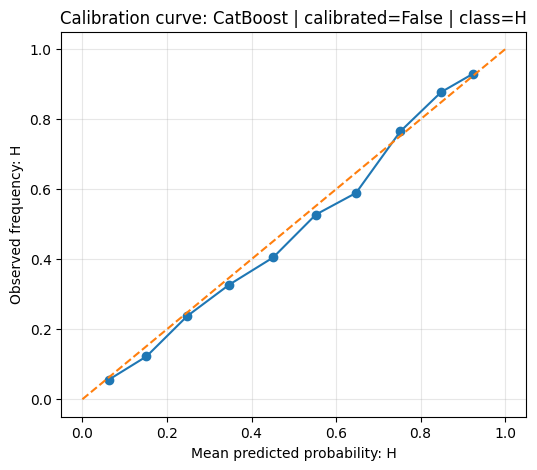

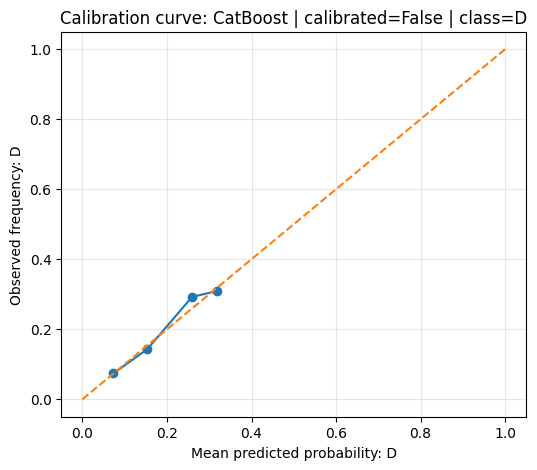

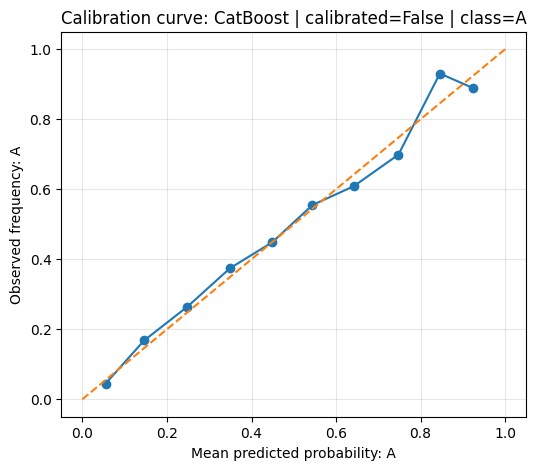

In [24]:
def plot_calibration_curves_for_model(
    predictions: pd.DataFrame,
    model_name: str,
    calibrated: bool,
    n_bins: int = 10,
):
    subset = predictions[
        predictions["model"].eq(model_name) &
        predictions["calibrated"].eq(calibrated)
    ].copy()

    if subset.empty:
        raise ValueError("No predictions found for selected model/calibration setting.")

    for cls in CLASS_ORDER:
        label = CLASS_LABELS[cls]
        y_binary = (subset["outcome"].eq(label)).astype(int)
        prob = subset[f"prob_{label}"]

        frac_pos, mean_pred = calibration_curve(
            y_binary,
            prob,
            n_bins=n_bins,
            strategy="uniform",
        )

        plt.figure(figsize=(6, 5))
        plt.plot(mean_pred, frac_pos, marker="o")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel(f"Mean predicted probability: {label}")
        plt.ylabel(f"Observed frequency: {label}")
        plt.title(f"Calibration curve: {model_name} | calibrated={calibrated} | class={label}")
        plt.grid(True, alpha=0.3)
        plt.show()


plot_calibration_curves_for_model(
    holdout_predictions,
    model_name=best_row["model"],
    calibrated=bool(best_row["calibrated"]),
)

## 17. Feature importance

For tree-based models, this cell tries to extract model feature importances after preprocessing. For other models, use permutation importance if needed.

,feature,importance
29,pi_rating_diff,31.650546
26,pi_expected_goal_diff,22.945033
0,neutral,5.060027
31,h2h_home_gd_avg_l5,3.323109
25,diff_form_matches_available_l10,2.461983
20,diff_form_ga_avg_l10,2.446910
12,diff_form_ga_avg_l5,1.913873
30,h2h_home_points_avg_l5,1.557990
32,h2h_matches_available_l5,1.518160
28,pi_away_travel_rating_diff,1.436644


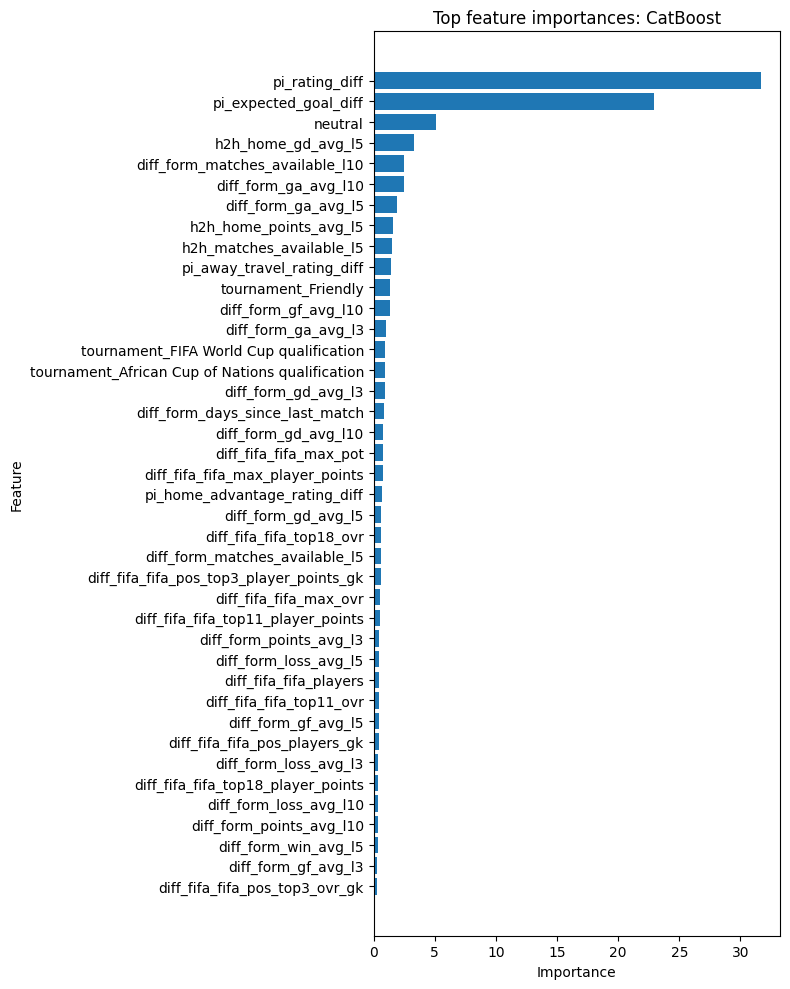

In [25]:
def get_preprocessed_feature_names(pipeline_or_calibrated) -> Optional[np.ndarray]:
    """Extract feature names from a fitted pipeline or calibrated pipeline."""
    est = pipeline_or_calibrated

    # CalibratedClassifierCV stores fitted estimators internally.
    if hasattr(est, "calibrated_classifiers_") and est.calibrated_classifiers_:
        inner = est.calibrated_classifiers_[0]
        if hasattr(inner, "estimator"):
            est = inner.estimator
        elif hasattr(inner, "base_estimator"):
            est = inner.base_estimator

    if not hasattr(est, "named_steps"):
        return None

    preprocess = est.named_steps.get("preprocess")
    if preprocess is None:
        return None

    try:
        return preprocess.get_feature_names_out()
    except Exception:
        return None


def get_final_model_object(pipeline_or_calibrated):
    est = pipeline_or_calibrated

    if hasattr(est, "calibrated_classifiers_") and est.calibrated_classifiers_:
        inner = est.calibrated_classifiers_[0]
        if hasattr(inner, "estimator"):
            est = inner.estimator
        elif hasattr(inner, "base_estimator"):
            est = inner.base_estimator

    if hasattr(est, "named_steps"):
        return est.named_steps.get("model")
    return est


feature_names = get_preprocessed_feature_names(best_model)
final_model_obj = get_final_model_object(best_model)

importance_df = None

if feature_names is not None and hasattr(final_model_obj, "feature_importances_"):
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": final_model_obj.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .head(40)
    )
    display(importance_df)

    plt.figure(figsize=(8, 10))
    plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top feature importances: {best_row['model']}")
    plt.tight_layout()
    plt.show()

elif feature_names is not None and hasattr(final_model_obj, "coef_"):
    coef = np.asarray(final_model_obj.coef_)
    importance = np.mean(np.abs(coef), axis=0)
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "mean_abs_coef": importance,
        })
        .sort_values("mean_abs_coef", ascending=False)
        .head(40)
    )
    display(importance_df)

else:
    print("Feature importance is not directly available for this best model.")
    print("Use sklearn.inspection.permutation_importance on the holdout set if you need model-agnostic importance.")

## 18. Predict upcoming fixtures

Fill `upcoming_matches` with home/away teams and dates, then run the same feature-building pipeline.

Important: upcoming predictions need historical matches already present in `matches` and FIFAIndex ratings available for the relevant game year.

In [26]:
# Example template. Replace with your own upcoming fixtures.
upcoming_matches = pd.DataFrame([
    # {"date": "2026-07-01", "home_team": "Example Home", "away_team": "Example Away", "neutral": False},
])

def build_upcoming_feature_rows(upcoming: pd.DataFrame):
    if upcoming.empty:
        return upcoming

    future = upcoming.copy()
    future["date"] = pd.to_datetime(future["date"], errors="coerce")
    future["home_score"] = 0
    future["away_score"] = 0
    future["home_team_norm"] = future["home_team"].map(normalize_name)
    future["away_team_norm"] = future["away_team"].map(normalize_name)
    if "neutral" not in future.columns:
        future["neutral"] = False

    # Append to historical matches only to create IDs and allow feature functions to run.
    hist_min_cols = matches[["date", "home_team", "away_team", "home_score", "away_score", "neutral", "home_team_norm", "away_team_norm"]].copy()
    combo = pd.concat([hist_min_cols, future[hist_min_cols.columns]], ignore_index=True)
    combo = combo.sort_values("date").reset_index(drop=True)
    combo["match_id"] = np.arange(len(combo), dtype=int)
    combo = add_outcome_target(combo)

    combo = merge_team_form(combo)
    combo = add_pi_ratings(combo)
    combo = add_h2h_features(combo)
    combo = merge_fifa_features(combo)

    future_keys = set(
        tuple(x) for x in future[["date", "home_team_norm", "away_team_norm"]].itertuples(index=False, name=None)
    )

    future_rows = combo[
        combo.apply(
            lambda r: (r["date"], r["home_team_norm"], r["away_team_norm"]) in future_keys,
            axis=1,
        )
    ].copy()

    # Rebuild X using the training feature columns exactly.
    X_future, _, meta_future, _, _ = build_model_matrix(future_rows)
    X_future = X_future.reindex(columns=bundle["feature_columns"], fill_value=np.nan)

    return X_future, meta_future


if upcoming_matches.empty:
    print("Add upcoming fixtures to the upcoming_matches DataFrame to generate predictions.")
else:
    X_future, meta_future = build_upcoming_feature_rows(upcoming_matches)
    future_proba = align_proba(best_model.predict_proba(X_future), best_model.classes_)

    pred = meta_future.reset_index(drop=True).copy()
    for i, cls in enumerate(CLASS_ORDER):
        pred[f"prob_{CLASS_LABELS[cls]}"] = future_proba[:, i]
    pred["pred_label"] = pred[[f"prob_{CLASS_LABELS[c]}" for c in CLASS_ORDER]].idxmax(axis=1).str.replace("prob_", "")
    display(pred)

Add upcoming fixtures to the upcoming_matches DataFrame to generate predictions.


## 19. Next tuning steps

Use this after the baseline notebook is running end-to-end:

1. Add team-name aliases when FIFA join coverage is low.
2. Tune Pi rating `alpha` and `away_home_transfer` by CV log loss.
3. Tune rolling windows, especially 5/10/20 match windows.
4. Add competition-strength features for club football.
5. Use only known pre-match lineups if you later build a true player availability table.
6. Compare a no-FIFA baseline versus FIFA + position features to measure added value.